# Task 4: Personal Expense Analytics
## Codtech IT Solutions – Data Analytics Internship

**Intern Name:** MD SAHIL ANSARI 

**Intern ID:** CITS3147 

**Domain:** Data Analytics  
**Task:** Task 4 – Personal Expense Analytics  
**Company:** Codtech IT Solutions Private Limited  

---

### Objective
To analyze personal expense data across 3 months (January–March 2024) and uncover spending patterns by category, payment mode, day of week, and month — helping individuals make smarter financial decisions and identify areas for saving.

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('personal_expenses.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Date Range    : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Total Expenses: ₹{df["Amount"].sum():,.0f}')
print(f'Categories    : {df["Category"].unique().tolist()}')
df.head(10)

Dataset Shape : 77 rows × 12 columns
Date Range    : 2024-01-01 to 2024-03-31
Total Expenses: ₹91,905
Categories    : ['Food & Dining', 'Transportation', 'Utilities', 'Entertainment', 'Health & Fitness', 'Shopping', 'Education']


,ExpenseID,Date,Category,Subcategory,Description,Amount,PaymentMode,Location,IsRecurring,Month,Week,DayOfWeek
0,E001,2024-01-01,Food & Dining,Groceries,Monthly grocery shopping,3200,UPI,BigBazaar,Yes,January,1,Monday
1,E002,2024-01-02,Transportation,Fuel,Petrol refill,1500,Cash,HP Petrol Pump,No,January,1,Tuesday
2,E003,2024-01-03,Food & Dining,Restaurant,Dinner with family,1800,Credit Card,Mainland China,No,January,1,Wednesday
3,E004,2024-01-05,Utilities,Electricity,Monthly electricity bill,1200,Net Banking,BSEB,Yes,January,1,Friday
4,E005,2024-01-06,Entertainment,OTT Subscription,Netflix monthly,649,Credit Card,Online,Yes,January,1,Saturday
5,E006,2024-01-07,Health & Fitness,Gym,Monthly gym membership,1500,UPI,Gold's Gym,Yes,January,2,Sunday
6,E007,2024-01-08,Food & Dining,Coffee,Morning coffee,180,UPI,Cafe Coffee Day,No,January,2,Monday
7,E008,2024-01-09,Shopping,Clothing,Winter jacket,2800,Credit Card,Myntra,No,January,2,Tuesday
8,E009,2024-01-10,Education,Books,Programming books,1200,UPI,Amazon,No,January,2,Wednesday
9,E010,2024-01-11,Transportation,Auto Rickshaw,Office commute,350,Cash,Local,No,January,2,Thursday


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ExpenseID    77 non-null     str           
 1   Date         77 non-null     datetime64[us]
 2   Category     77 non-null     str           
 3   Subcategory  77 non-null     str           
 4   Description  77 non-null     str           
 5   Amount       77 non-null     int64         
 6   PaymentMode  77 non-null     str           
 7   Location     77 non-null     str           
 8   IsRecurring  77 non-null     str           
 9   Month        77 non-null     str           
 10  Week         77 non-null     int64         
 11  DayOfWeek    77 non-null     str           
dtypes: datetime64[us](1), int64(2), str(9)
memory usage: 7.3 KB


In [4]:
print('=== Statistical Summary ===')
df[['Amount']].describe().T

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
Amount,77.0,1193.571429,916.497429,160.0,450.0,999.0,1500.0,4500.0


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values. Dataset is clean!')

=== Missing Values ===
No missing values. Dataset is clean!


## Step 4: Spending by Category

### 4.1 Total Spending by Category

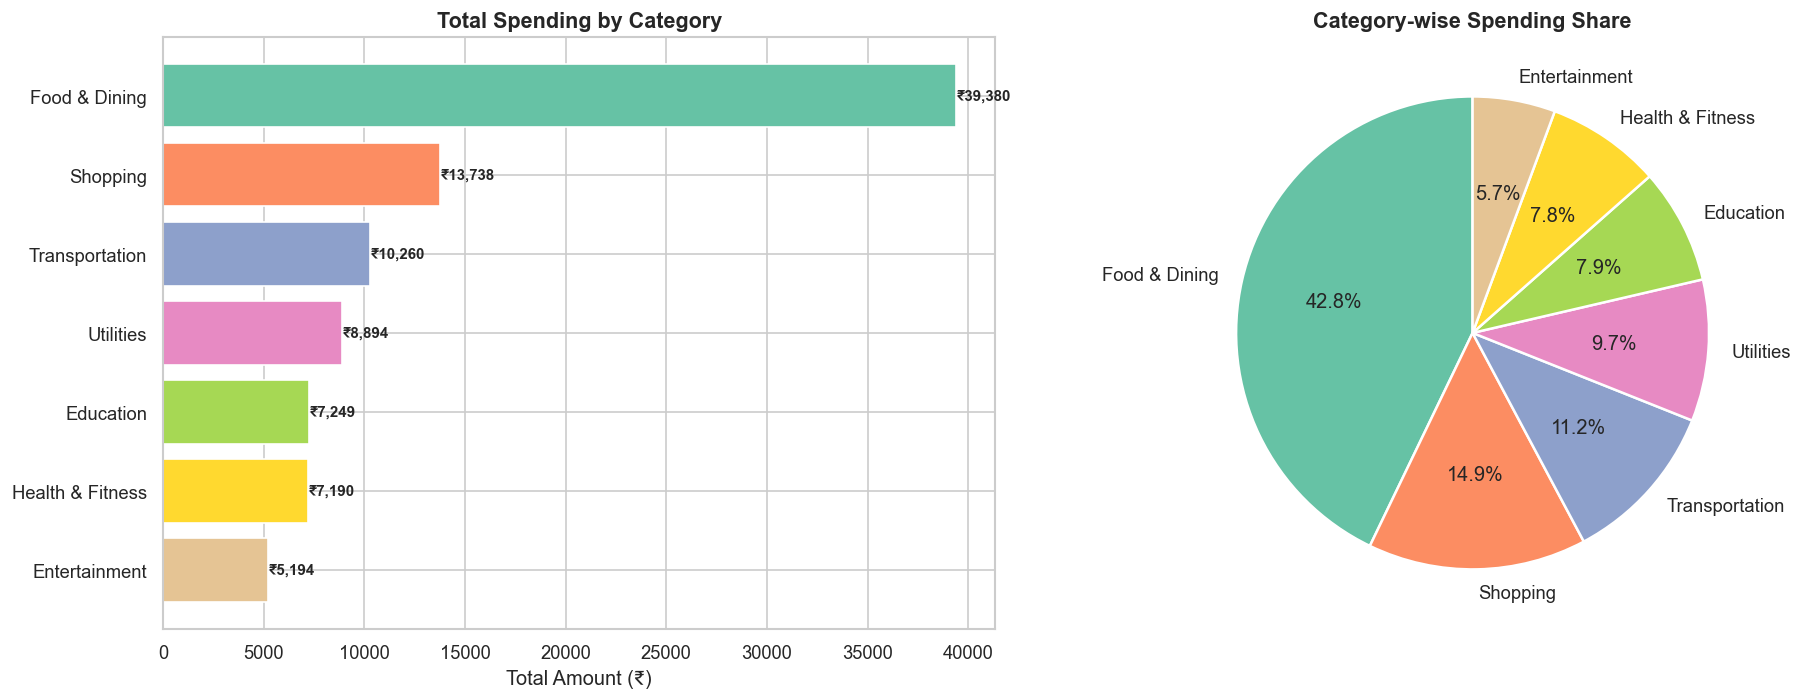


=== Category-wise Spending Summary ===
                  Total (₹)  Share (%)
Category                              
Food & Dining         39380      42.85
Shopping              13738      14.95
Transportation        10260      11.16
Utilities              8894       9.68
Education              7249       7.89
Health & Fitness       7190       7.82
Entertainment          5194       5.65


In [6]:
cat_spend = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(cat_spend))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].barh(cat_spend.index[::-1], cat_spend.values[::-1], color=colors[::-1], edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'₹{bar.get_width():,.0f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Spending by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Amount (₹)')

axes[1].pie(cat_spend, labels=cat_spend.index, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Category-wise Spending Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('spending_by_category.png', bbox_inches='tight')
plt.show()

print('\n=== Category-wise Spending Summary ===')
cat_table = pd.DataFrame({'Total (₹)': cat_spend, 'Share (%)': (cat_spend / cat_spend.sum() * 100).round(2)})
print(cat_table)

### 4.2 Subcategory Breakdown

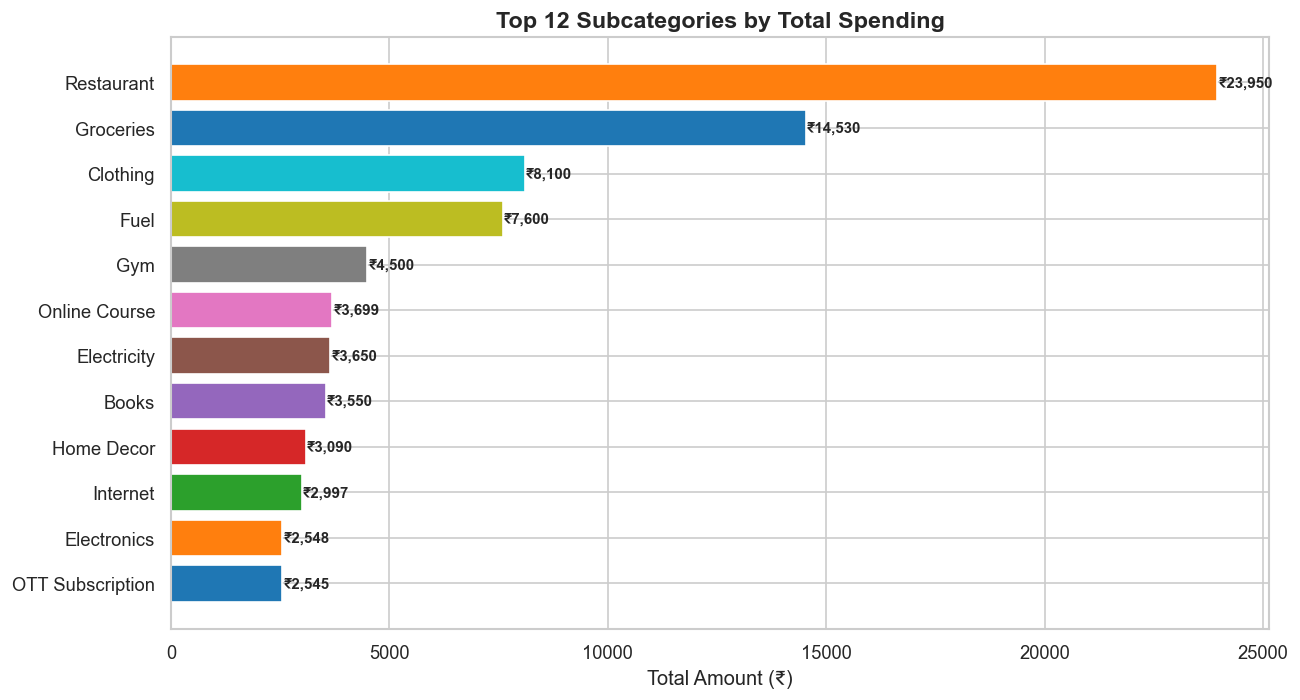

In [7]:
subcat_spend = df.groupby('Subcategory')['Amount'].sum().sort_values(ascending=True).tail(12)

plt.figure(figsize=(11, 6))
bars = plt.barh(subcat_spend.index, subcat_spend.values,
                color=sns.color_palette('tab10', len(subcat_spend)), edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():,.0f}', va='center', fontsize=9, fontweight='bold')
plt.title('Top 12 Subcategories by Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount (₹)')
plt.tight_layout()
plt.savefig('subcategory_spending.png', bbox_inches='tight')
plt.show()

## Step 5: Monthly Spending Analysis

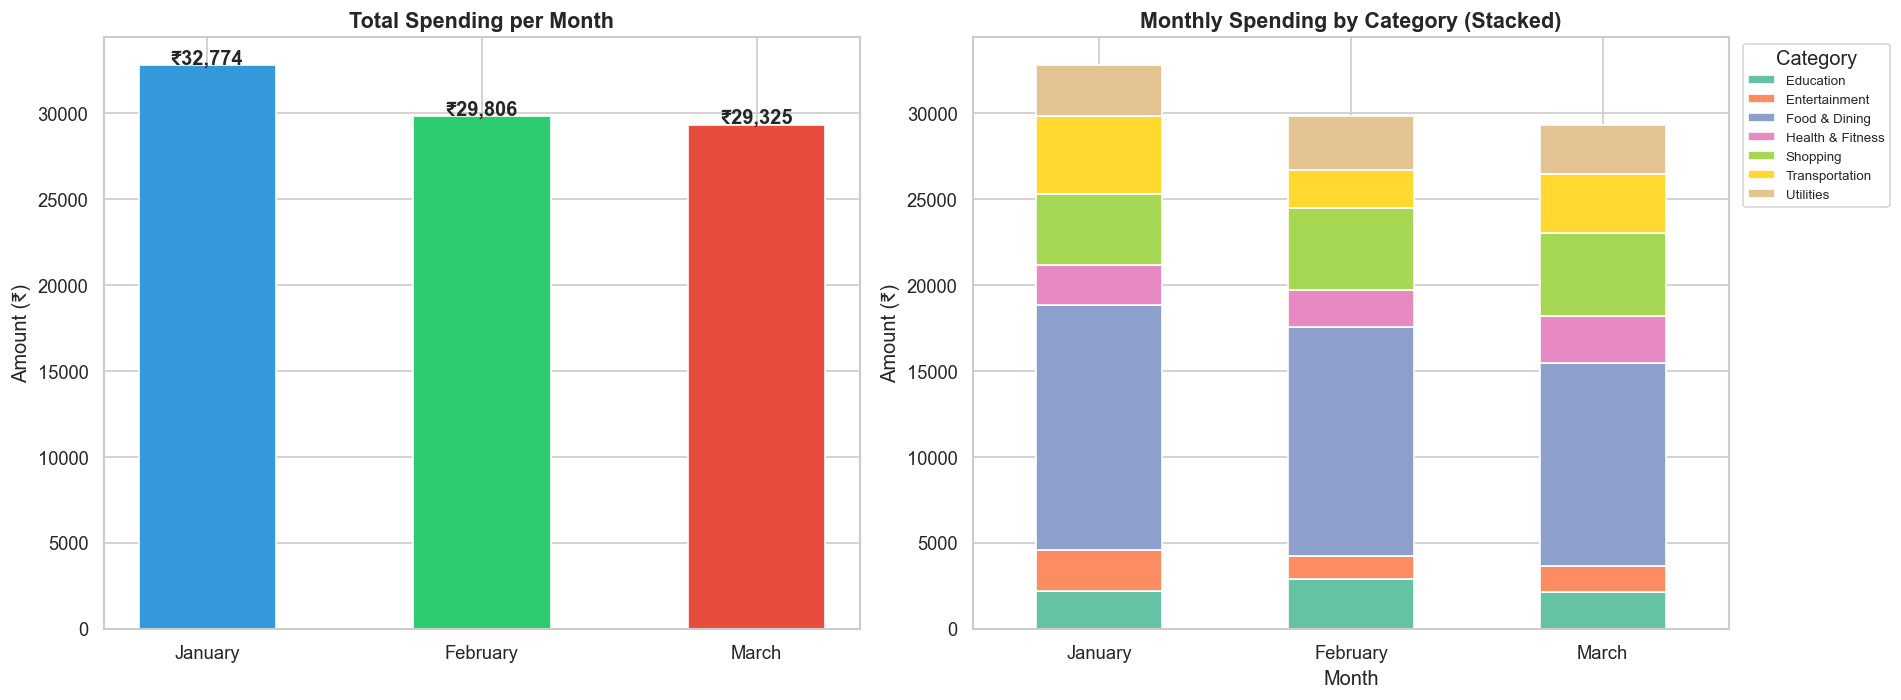

In [8]:
month_order = ['January', 'February', 'March']
monthly_total = df.groupby('Month')['Amount'].sum().reindex(month_order)
monthly_cat = df.groupby(['Month', 'Category'])['Amount'].sum().unstack(fill_value=0).reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bar_colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(monthly_total.index, monthly_total.values, color=bar_colors, edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'₹{bar.get_height():,.0f}', ha='center', fontweight='bold')
axes[0].set_title('Total Spending per Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (₹)')

monthly_cat.plot(kind='bar', stacked=True, ax=axes[1],
                 color=sns.color_palette('Set2', len(monthly_cat.columns)), edgecolor='white')
axes[1].set_title('Monthly Spending by Category (Stacked)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount (₹)')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('monthly_spending.png', bbox_inches='tight')
plt.show()

## Step 6: Daily Spending Trend

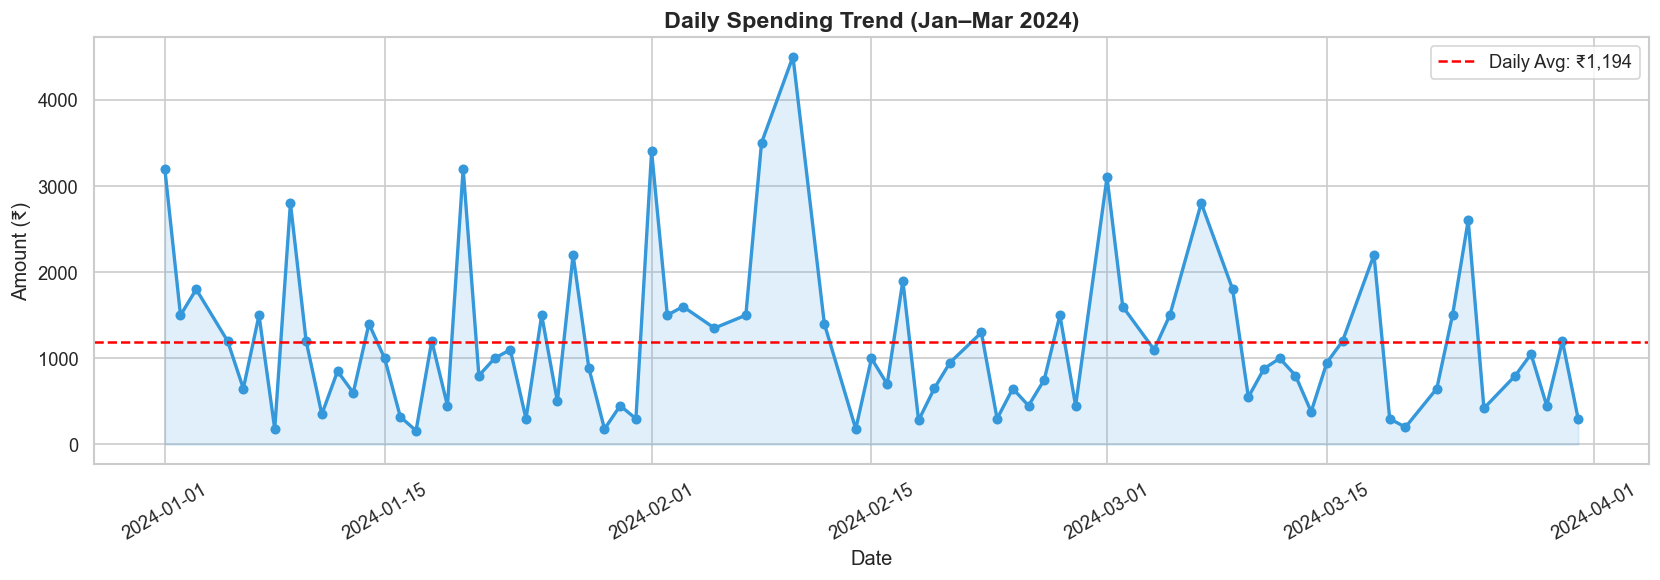

In [9]:
daily_spend = df.groupby('Date')['Amount'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_spend.index, daily_spend.values, color='#3498db', linewidth=2, marker='o', markersize=5)
plt.fill_between(daily_spend.index, daily_spend.values, alpha=0.15, color='#3498db')
plt.axhline(daily_spend.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Daily Avg: ₹{daily_spend.mean():,.0f}')
plt.title('Daily Spending Trend (Jan–Mar 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Amount (₹)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('daily_spending_trend.png', bbox_inches='tight')
plt.show()

## Step 7: Payment Mode Analysis

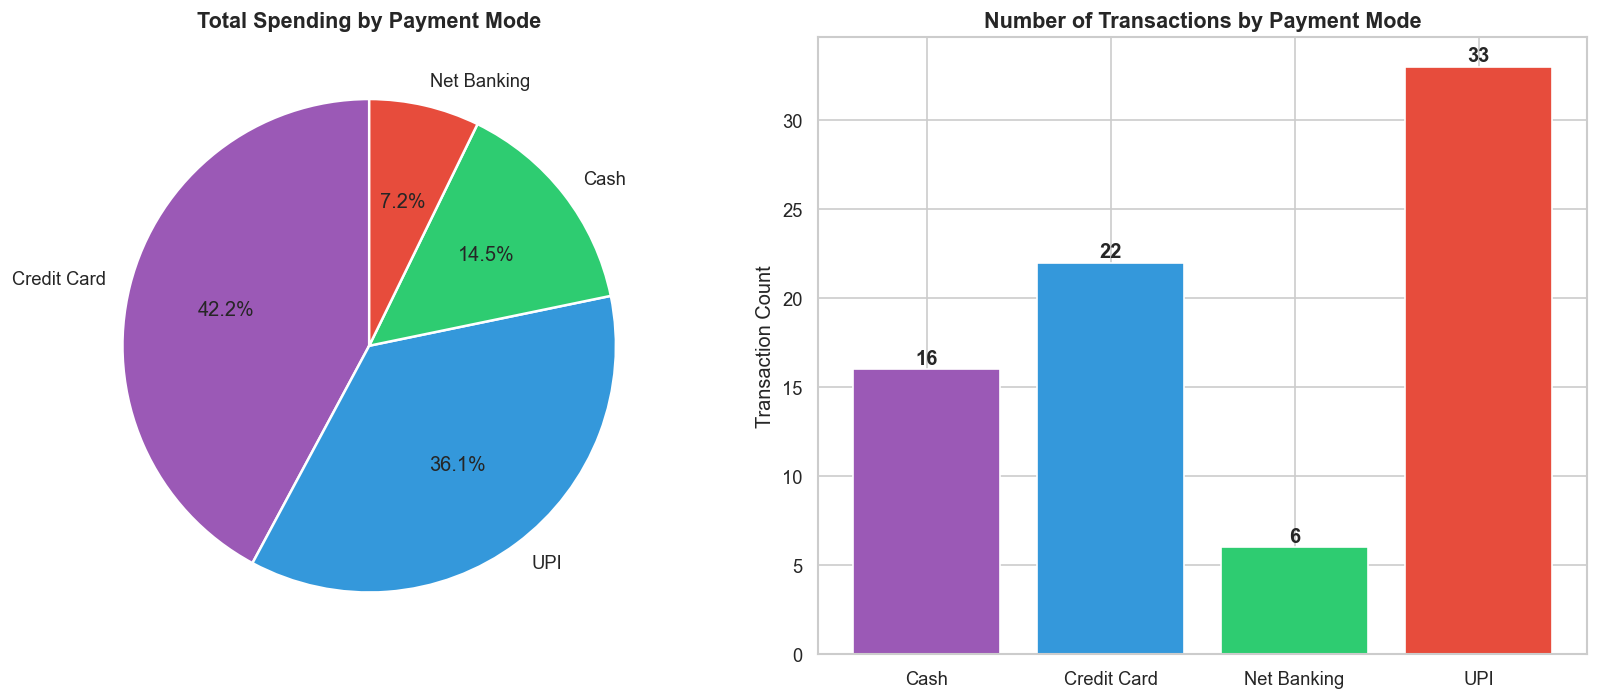


=== Payment Mode Summary ===
             Total Spent (₹)  Transactions  Avg per Transaction (₹)
PaymentMode                                                        
Cash                   13350            16                    834.0
Credit Card            38743            22                   1761.0
Net Banking             6647             6                   1108.0
UPI                    33165            33                   1005.0


In [10]:
payment_spend = df.groupby('PaymentMode')['Amount'].sum().sort_values(ascending=False)
payment_count = df.groupby('PaymentMode')['Amount'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pay_colors = ['#9b59b6', '#3498db', '#2ecc71', '#e74c3c']
axes[0].pie(payment_spend, labels=payment_spend.index, autopct='%1.1f%%', startangle=90,
            colors=pay_colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Total Spending by Payment Mode', fontsize=13, fontweight='bold')

bars = axes[1].bar(payment_count.index, payment_count.values, color=pay_colors, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[1].set_title('Number of Transactions by Payment Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.savefig('payment_mode.png', bbox_inches='tight')
plt.show()

print('\n=== Payment Mode Summary ===')
pay_df = pd.DataFrame({'Total Spent (₹)': payment_spend, 'Transactions': payment_count})
pay_df['Avg per Transaction (₹)'] = (pay_df['Total Spent (₹)'] / pay_df['Transactions']).round(0)
print(pay_df)

## Step 8: Spending by Day of Week

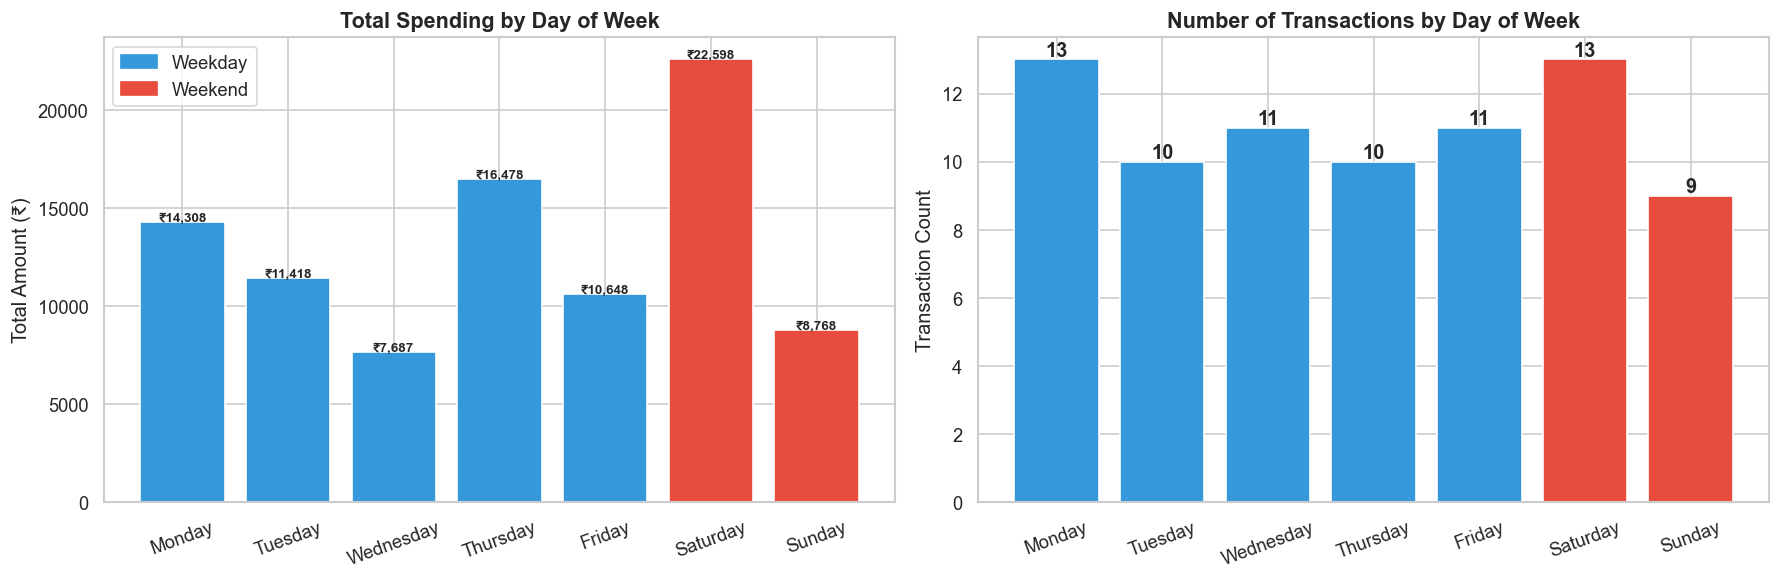

In [11]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_spend = df.groupby('DayOfWeek')['Amount'].sum().reindex(day_order)
day_count = df.groupby('DayOfWeek')['Amount'].count().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

weekend_colors = ['#3498db' if d not in ['Saturday','Sunday'] else '#e74c3c' for d in day_order]
bars = axes[0].bar(day_spend.index, day_spend.values, color=weekend_colors, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'₹{bar.get_height():,.0f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Total Spending by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Amount (₹)')
axes[0].tick_params(axis='x', rotation=20)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#3498db', label='Weekday'),
                         Patch(color='#e74c3c', label='Weekend')])

bars2 = axes[1].bar(day_count.index, day_count.values, color=weekend_colors, edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[1].set_title('Number of Transactions by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Transaction Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('spending_by_day.png', bbox_inches='tight')
plt.show()

## Step 9: Recurring vs Non-Recurring Expenses

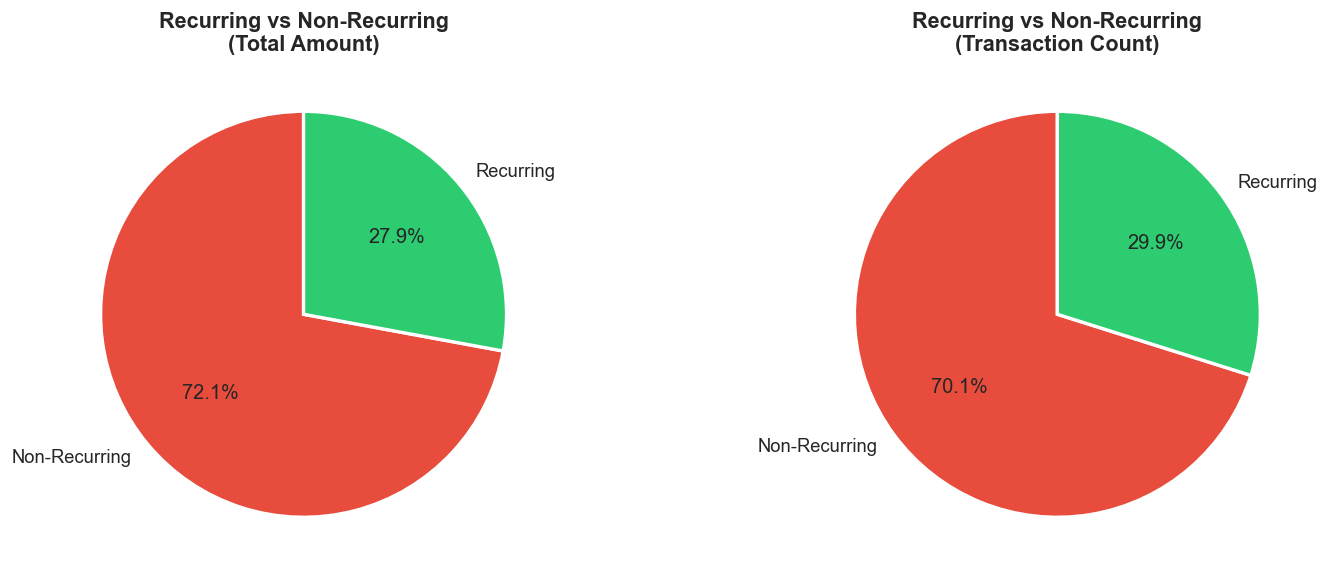


=== Recurring Expense Breakdown ===
               Total Amount (₹)  Transactions
Non-Recurring             66266            54
Recurring                 25639            23


In [12]:
recurring = df.groupby('IsRecurring')['Amount'].agg(['sum', 'count'])
recurring.index = ['Non-Recurring', 'Recurring']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(recurring['sum'], labels=recurring.index, autopct='%1.1f%%', startangle=90,
            colors=['#e74c3c', '#2ecc71'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Recurring vs Non-Recurring\n(Total Amount)', fontsize=13, fontweight='bold')

axes[1].pie(recurring['count'], labels=recurring.index, autopct='%1.1f%%', startangle=90,
            colors=['#e74c3c', '#2ecc71'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Recurring vs Non-Recurring\n(Transaction Count)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('recurring_expenses.png', bbox_inches='tight')
plt.show()

print('\n=== Recurring Expense Breakdown ===')
print(recurring.rename(columns={'sum': 'Total Amount (₹)', 'count': 'Transactions'}))

## Step 10: Heatmap – Category vs Month

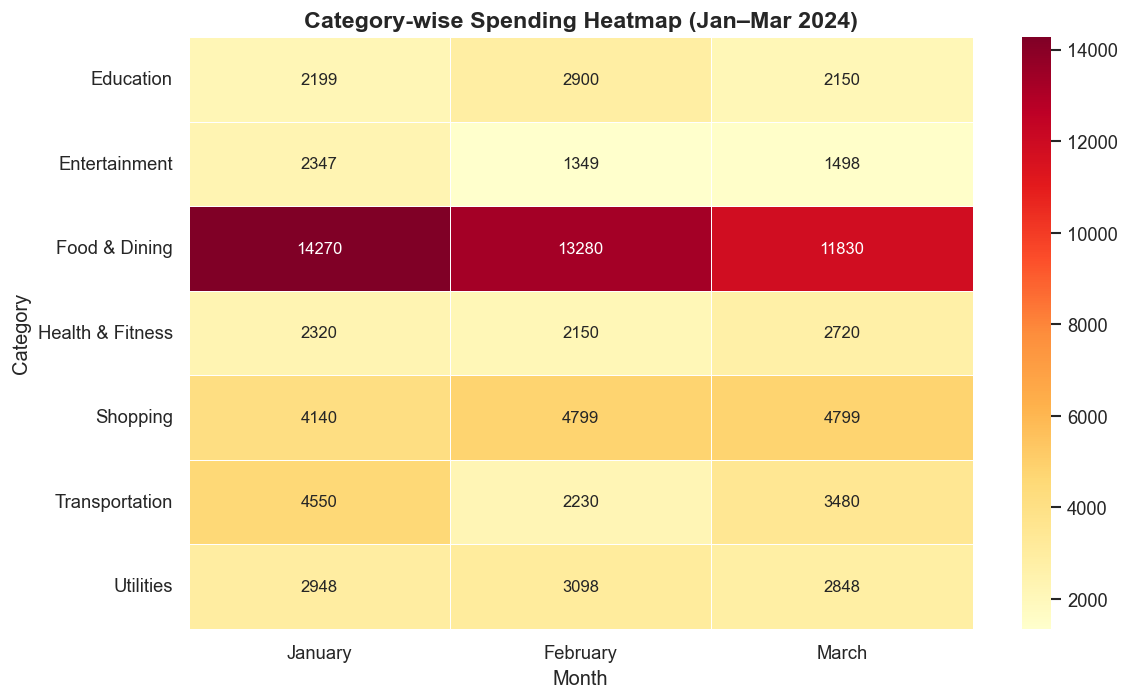

In [13]:
heatmap_data = df.pivot_table(index='Category', columns='Month',
                               values='Amount', aggfunc='sum')[month_order].fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Category-wise Spending Heatmap (Jan–Mar 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_month_heatmap.png', bbox_inches='tight')
plt.show()

## Step 11: Top 10 Highest Individual Expenses

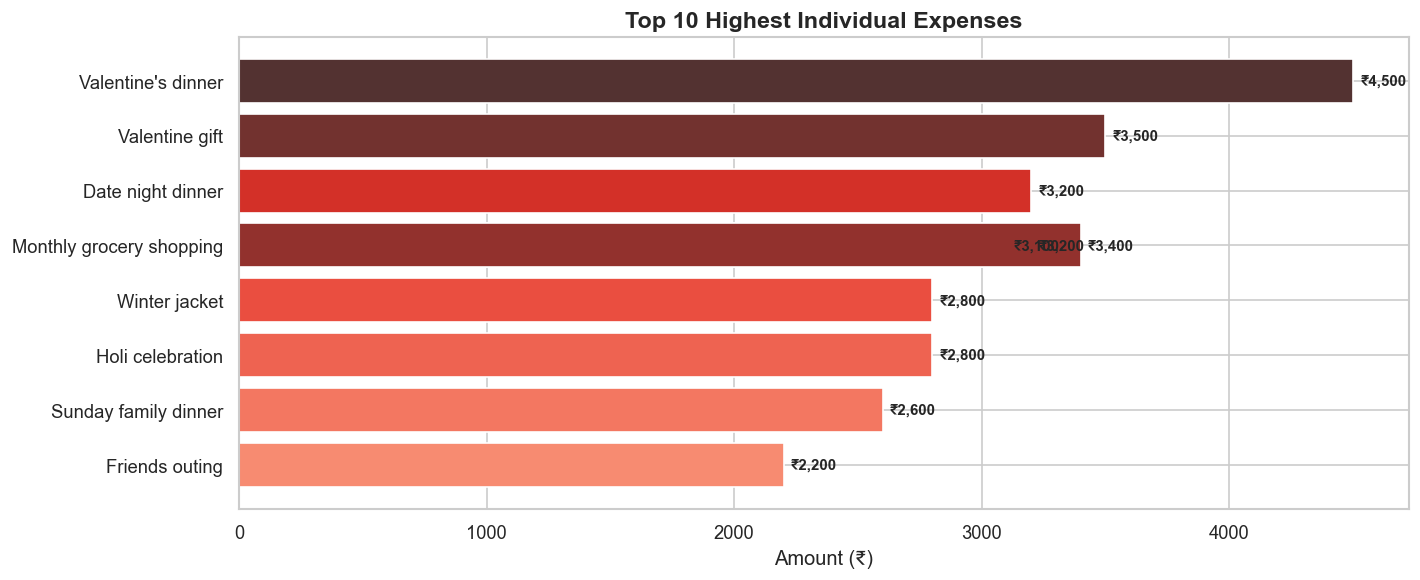


=== Top 10 Expenses ===
      Date      Category Subcategory              Description  Amount PaymentMode
2024-02-10 Food & Dining  Restaurant       Valentine's dinner    4500 Credit Card
2024-02-08      Shopping    Clothing           Valentine gift    3500 Credit Card
2024-02-01 Food & Dining   Groceries Monthly grocery shopping    3400         UPI
2024-01-01 Food & Dining   Groceries Monthly grocery shopping    3200         UPI
2024-01-20 Food & Dining  Restaurant        Date night dinner    3200 Credit Card
2024-03-01 Food & Dining   Groceries Monthly grocery shopping    3100         UPI
2024-01-09      Shopping    Clothing            Winter jacket    2800 Credit Card
2024-03-07 Food & Dining  Restaurant         Holi celebration    2800 Credit Card
2024-03-24 Food & Dining  Restaurant     Sunday family dinner    2600 Credit Card
2024-01-27 Food & Dining  Restaurant           Friends outing    2200 Credit Card


In [14]:
top10 = df.nlargest(10, 'Amount')[['Date', 'Category', 'Subcategory', 'Description', 'Amount', 'PaymentMode']]

plt.figure(figsize=(12, 5))
bars = plt.barh(top10['Description'][::-1], top10['Amount'][::-1],
                color=sns.color_palette('Reds_d', 10), edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():,.0f}', va='center', fontsize=9, fontweight='bold')
plt.title('Top 10 Highest Individual Expenses', fontsize=14, fontweight='bold')
plt.xlabel('Amount (₹)')
plt.tight_layout()
plt.savefig('top10_expenses.png', bbox_inches='tight')
plt.show()

print('\n=== Top 10 Expenses ===')
print(top10.to_string(index=False))

## Step 12: Budget vs Actual Spending (Assumed Budget)

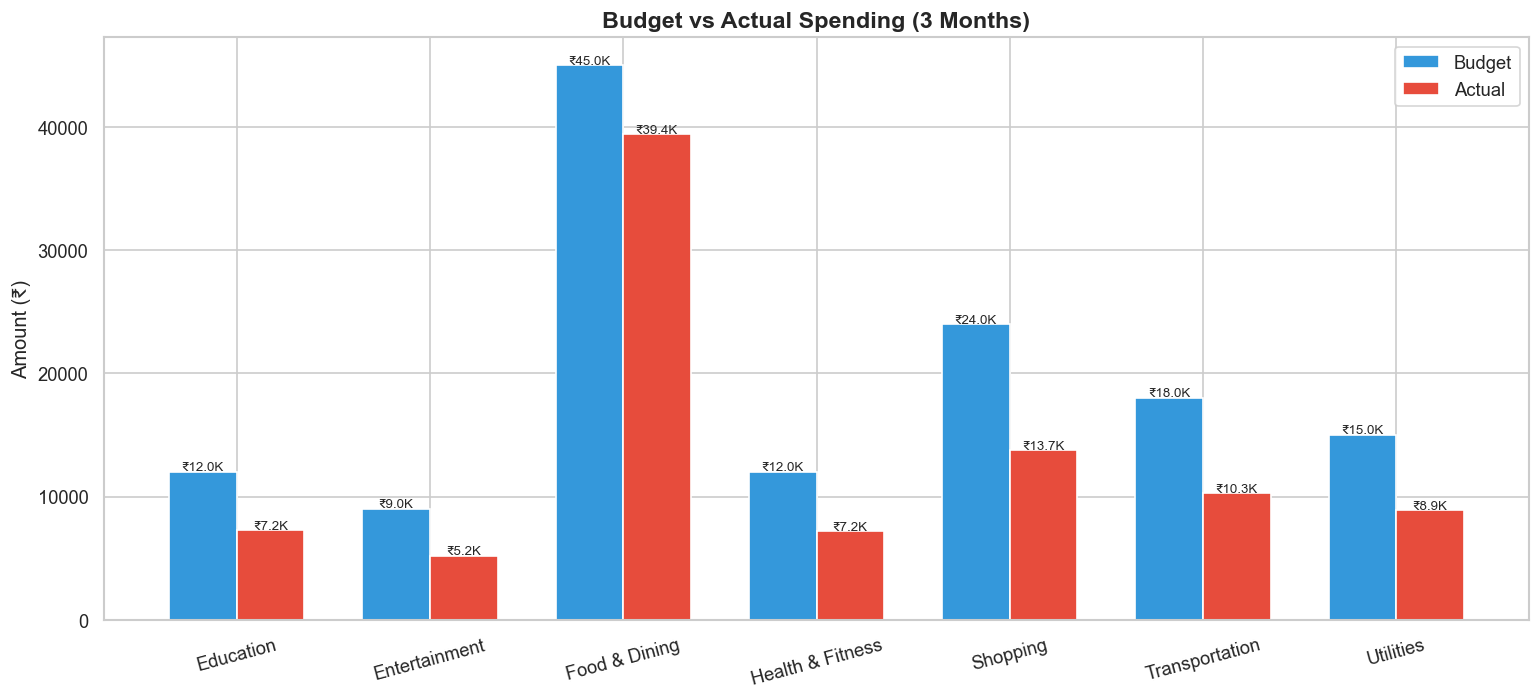


=== Budget vs Actual Summary ===
                  Budget (3M)  Actual (3M)  Difference (₹)          Status
Education               12000         7249            4751  ✅ Under Budget
Entertainment            9000         5194            3806  ✅ Under Budget
Food & Dining           45000        39380            5620  ✅ Under Budget
Health & Fitness        12000         7190            4810  ✅ Under Budget
Shopping                24000        13738           10262  ✅ Under Budget
Transportation          18000        10260            7740  ✅ Under Budget
Utilities               15000         8894            6106  ✅ Under Budget


In [15]:
# Assumed monthly budget per category
budget = {
    'Food & Dining'   : 15000,
    'Transportation'  : 6000,
    'Utilities'       : 5000,
    'Shopping'        : 8000,
    'Entertainment'   : 3000,
    'Health & Fitness': 4000,
    'Education'       : 4000
}

actual = df.groupby('Category')['Amount'].sum()
budget_df = pd.DataFrame({'Budget (3M)': {k: v*3 for k,v in budget.items()},
                           'Actual (3M)': actual}).dropna()

x = np.arange(len(budget_df))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width/2, budget_df['Budget (3M)'], width, label='Budget', color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, budget_df['Actual (3M)'], width, label='Actual', color='#e74c3c', edgecolor='white')
ax.set_title('Budget vs Actual Spending (3 Months)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(budget_df.index, rotation=15)
ax.set_ylabel('Amount (₹)')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'₹{bar.get_height()/1000:.1f}K', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('budget_vs_actual.png', bbox_inches='tight')
plt.show()

budget_df['Difference (₹)'] = budget_df['Budget (3M)'] - budget_df['Actual (3M)']
budget_df['Status'] = budget_df['Difference (₹)'].apply(lambda x: '✅ Under Budget' if x >= 0 else '❌ Over Budget')
print('\n=== Budget vs Actual Summary ===')
print(budget_df)

## Step 13: Key Insights & Conclusion

---

### 📊 Key Findings:

1. **Largest Spending Category:** **Food & Dining** consistently accounts for the highest share of total expenses across all three months — restaurants and groceries are the dominant subcategories.

2. **Monthly Trend:** Spending peaked in **February** due to Valentine's Day-related shopping and dining expenses, highlighting how events/festivals significantly influence personal budgets.

3. **Payment Mode:** **UPI** is the most frequently used payment method, followed by Credit Card — reflecting the shift toward digital payments in everyday spending.

4. **Weekend Splurge:** Saturdays and Sundays show noticeably higher spending, driven primarily by restaurant outings, shopping, and entertainment — typical weekend behavior.

5. **Recurring Expenses:** Fixed recurring expenses (gym, subscriptions, bills) account for a significant predictable portion of the monthly budget and should be factored into financial planning.

6. **Top Single Expense:** The Valentine's dinner and special occasion dining were the highest single-day expenses, emphasizing the impact of impulse or event-based spending.

7. **Budget Adherence:** Most categories stayed within the assumed budget. However, **Food & Dining** and **Shopping** showed a tendency to exceed targets, indicating areas that need better discipline.

---

### ✅ Recommendations:
- **Set strict limits** on restaurant spending by meal-prepping and cooking at home more often.
- **Track weekend spending** — a significant portion of excess spending occurs on Saturdays and Sundays.
- **Plan for seasonal events** (Valentine's Day, Holi, etc.) with dedicated event budgets to avoid overshooting.
- **Leverage UPI cashback offers** and credit card reward points to reduce net spending.
- **Automate savings** before discretionary spending to enforce budgeting discipline.

---
*Analysis completed as part of Codtech IT Solutions Data Analytics Internship – Task 4*